In [1]:
# Standard-library
import json
import pathlib
import sys
from types import SimpleNamespace

# Third-party
import dill
import numpy as np
import pandas as pd
import simpeg.electromagnetics.time_domain as tdem
from ipywidgets import VBox, interact, interactive_output, widgets
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from rich import print
from simpeg.electromagnetics.utils.em1d_utils import (
    get_vertical_discretization,
)
from simpeg.utils import plot_1d_layer_model


In [2]:
def get_active_edge_indices_with_distance(
    mesh_radial, mesh_vertical, maximum_distance=1000
    ):
    nz = mesh_vertical.n_cells
    edge_lengths = mesh_radial.edge_lengths
    inds = edge_lengths < maximum_distance
    indActiveEdges = np.tile(inds.reshape([-1, 1]), nz).flatten()
    return inds, indActiveEdges

In [3]:
sys.path.append(str(pathlib.Path("../tools")))
import tools

/Volumes/X31/01.Projects/atem/notebooks
Current working directory is changed to: /Volumes/X31/01.Projects/atem


In [4]:
start_channel:int = 3
end_channel:int = 25
conf = json.load(
    open(
        "./data/atem.json"
    )
)
times = np.array(conf["channels"])[start_channel:end_channel] * 1e-6
n_turns = conf["n_turns"]

In [5]:
area:str = "NE"
path:str = f"./data/obs/11-024_Alberta_{area}.csv"

In [6]:
tmp:dict = tools.binning(dx=50, area=area)

In [7]:
times = tmp["times"]
n_turns = tmp["n_turns"]
dheader = tmp["dheader"]
picker = tmp["picker"]
values = tmp["values"]
values_std = tmp["values_std"]
soundings = tmp["soundings"]

In [8]:
def plot_data(line, x):
    print(line)
    x_line = x[x["Line"]==line]

    fig, axs = plt.subplots(2,1, figsize=(20, 10), constrained_layout=True)
    ax0, ax1 = axs

    # (ax0) Plot the binned locations
    ax0.plot(x["x_wgs84"], x["y_wgs84"], '.')
    ax0.plot(x_line["x_wgs84"], x_line["y_wgs84"], '.')
    ax0.plot(x_line["x_wgs84"].values[0], x_line["y_wgs84"].values[0], 'o')
    ax0.set_aspect(0.2)

    # (ax1) Plot the normalized data
    ax2 = ax1.twinx()
    ax1.semilogy(x_line['distance'], np.abs(x_line[dheader]), color='k', lw=2)
    ax2.plot(x_line['distance'], x_line['bheight'], '-', label='Flight height', lw=1.5, color='magenta')
    ax2.legend()
    plt.title(f"Line: {line}")

In [9]:
df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance'] + picker[1:])
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['bheight'] + dheader)

In [10]:
line_no = list(df_data_binned['Line'].unique())

In [11]:
df_data_binned = pd.DataFrame(
    data=np.vstack(values),
    columns = ['Line', 'distance'] + picker[1:]
)
df_data_std_binned = pd.DataFrame(
    data=np.vstack(values_std),
    columns = ['bheight'] + dheader
)

In [12]:
istart = 0
iend = None
line_widget = widgets.SelectionSlider(
    options=line_no[istart:iend],
    value=line_no[istart],
    description="Line",
)
interact(plot_data, line=line_widget, x=widgets.fixed(df_data_binned))

interactive(children=(SelectionSlider(description='Line', options=('L10040', 'L10050', 'L10051', 'L10060', 'L1…

<function __main__.plot_data(line, x)>

In [13]:
selected_line = ["L10100", "L10110", "L10120", "L10130"]

In [14]:
idxx = df_data_binned['Line'].isin(selected_line)
df_data_binned = df_data_binned[idxx]
df_data_std_binned = df_data_std_binned[idxx]

selected_soundings = [len(df_data_binned[df_data_binned['Line']==line]) for line in selected_line ]

In [15]:
for col in df_data_binned.columns:
    if col != "Line":
        df_data_binned[col] = pd.to_numeric(df_data_binned[col])

print(f"\tBinned soundings: {len(df_data_binned):,}\n")

# Criteria for bad data (uncertainty correction)
data_ = df_data_binned[dheader].values.astype(float)
data_rerr = (
    df_data_std_binned[dheader].values / np.abs(df_data_binned[dheader].values)
).astype(float)

Binned soundings: 4,757

In [16]:
criteria_rerr: float = 0.05  # Select binned data having high std.
criteria_uncertainty: float = (
    0.05  # Select how much uncertainty will be used for normalization.
)

channel_id = np.tile(np.arange(data_.shape[1]), (data_.shape[0], 1))
cut_off = (data_rerr > criteria_rerr) * (channel_id >= 0)
floors_c: float = 0.05
floors = 5 * 1e-9 / (df_data_binned["TranPeak"] * n_turns) * floors_c

del data_, data_rerr
dobs = df_data_binned[dheader].values.flatten()  # Binned Data
std = df_data_std_binned[
    dheader
].values.flatten()  # Standard deviation of Binned Data
dobs_std = abs(dobs) * criteria_uncertainty  # 0.05 * Binned Data
dobs_std[std > dobs_std] = std[
    std > dobs_std
]  # Standard deviation having smaller than 0.05 * dobs will be replaced with 0.05 * dobs.
# dobs_std[bad_line_mask.flatten()] = (
#     abs(dobs[bad_line_mask.flatten()]) * bad_line_uncertainty
# )
dobs_std[cut_off.flatten()] = (
    np.inf
)  # Filter out bad data by setting their standard deviation to infinity
dobs_std += np.repeat(floors.values, end_channel - start_channel)  # Add floors

In [17]:
print("02. Discretization\n")
# Set topography and transmitter heights
topography = df_data_binned[["x_wgs84", "y_wgs84", "dtm"]].values
source_heights = df_data_binned["bheight"].values
thickness = get_vertical_discretization(21, 2, 1.17)

# Waveform
start_time = -1.74e-3
peak_time = -0.84e-3
off_time = 0.0

waveform = tdem.sources.TriangularWaveform(start_time, off_time, peak_time)

current_times = np.linspace(start_time, off_time)
currents = [waveform.eval(t) for t in current_times]

radius: float = 5.0

input_data_dict = {
    "topography": topography.astype(float),
    "source_heights": source_heights.astype(float),
    "thickness": thickness,
    "time_input_currents": current_times,
    "input_currents": currents,
    "times": times,
    "data": dobs,
    "data_std": dobs_std,
}
inp = SimpleNamespace(**input_data_dict)

source_locations = np.c_[
    inp.topography[:, 0],
    inp.topography[:, 1],
    inp.topography[:, 2] + inp.source_heights,
]
receiver_locations = np.c_[
    inp.topography[:, 0],
    inp.topography[:, 1],
    inp.topography[:, 2] + inp.source_heights,
]
n_sounding = source_locations.shape[0]

source_list = []
receiver_orientation = "z"
source_orientation = "z"


02. Discretization

>> Depth from the surface to the base of the bottom layer is 306.3m


In [18]:
n_sounding

4757

In [19]:
hz = np.r_[thickness, thickness[-1]]
n_layer = len(hz)
depth_edges = np.r_[0.0, np.cumsum(hz)]
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])

In [20]:
with open("./outputs/chi/sharp_2.5chi_inv_results_atem_full.pik", "rb") as f:
    outDict1 = dill.load(f)
with open("./outputs/chi/sharp_3chi_inv_results_atem_full.pik", "rb") as f:
    outDict2 = dill.load(f)
with open("./outputs/chi/sharp_4chi_inv_results_atem_full.pik", "rb") as f:
    outDict3 = dill.load(f)

In [21]:
print(outDict1.keys())
print(outDict2.keys())
print(outDict3.keys())

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 
29, 30])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 
29, 30])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 
29, 30])

In [22]:
miter = 30

In [23]:
phi_d1 = [outDict1[i]['phi_d'] for i in range(1, miter + 1)]
phi_m1 = [outDict1[i]['phi_m'] for i in range(1, miter + 1)]
phi_d2 = [outDict2[i]['phi_d'] for i in range(1, miter + 1)]
phi_m2 = [outDict2[i]['phi_m'] for i in range(1, miter + 1)]
phi_d3 = [outDict3[i]['phi_d'] for i in range(1, miter + 1)]
phi_m3 = [outDict3[i]['phi_m'] for i in range(1, miter + 1)]

In [24]:
no_of_data_points1 = outDict1[1]['dpred'].shape[0]
chi_squared1 = np.array(phi_d1) / no_of_data_points1
chi_squared2 = np.array(phi_d2) / no_of_data_points1
chi_squared3 = np.array(phi_d3) / no_of_data_points1
print(f"chi squared: {chi_squared1}")
print(f"chi squared: {chi_squared2}")
print(f"chi squared: {chi_squared3}")

chi squared: [25.38675022  3.06667273  1.4780832   0.95334109  1.01639551  1.20919387
  1.46177492  1.57567238  1.63899221  1.65978873  1.64845048  1.62680647
  1.60034018  1.57666495  1.55681205  1.54049724  1.52723035  1.51642473
  1.5075528   1.49981448  1.4925503   1.48589143  1.47916462  1.47231532
  1.46521466  1.45776929  1.45036967  1.44196061  1.43332964  1.42419054]

chi squared: [25.46825801  3.14369998  1.40037093  0.98734319  1.01998119  1.24270598
  1.54426371  1.70970503  1.82299143  1.87120472  1.87319467  1.85158778
  1.8246266   1.79737866  1.77404675  1.75400276  1.7377537   1.72421431
  1.71359032  1.7052871   1.69835537  1.69242109  1.68718125  1.68225799
  1.67763149  1.67295752  1.6684082   1.66372628  1.65879038  1.65365258]

chi squared: [25.70909025  3.29692809  1.2544493   1.45808002  1.90885169  2.37156466
  2.57173057  2.88753285  2.83110137  2.83739931  2.73068692  2.62978544
  2.53690666  2.46036442  2.40056829  2.35487142  2.31885408  2.29054163
  2.26783962  2.2490394   2.23249524  2.21830135  2.2052708   2.19330669
  2.18249755  2.17093475  2.15957707  2.15033067  2.14045886  2.13231129]

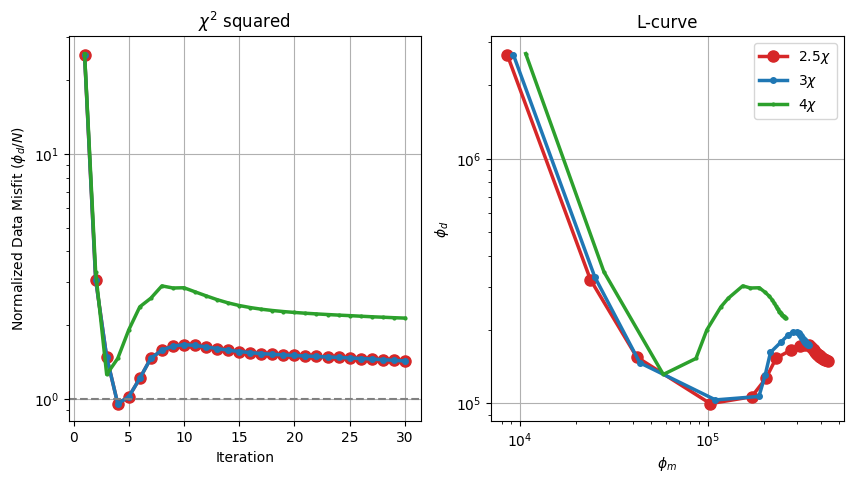

In [25]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, miter + 1), chi_squared1, marker='o', color='tab:red', linewidth=2.5, markersize=8)
plt.plot(range(1, miter + 1), chi_squared1, marker='o', color='tab:blue', linewidth=2.5, markersize=4)
plt.plot(range(1, miter + 1), chi_squared3, marker='o', color='tab:green', linewidth=2.5, markersize=2)
plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, label='Target $\chi^2$')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Normalized Data Misfit ($\phi_d / N$)')
plt.title("$\chi^2$ squared")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(phi_m1, phi_d1, marker='o', color='tab:red', linewidth=2.5, markersize=8)
plt.plot(phi_m2, phi_d2, marker='o', color='tab:blue', linewidth=2.5, markersize=4)
plt.plot(phi_m3, phi_d3, marker='o', color='tab:green', linewidth=2.5, markersize=2)
plt.xscale('log')
plt.yscale('log')
plt.title("L-curve")
plt.xlabel("$\phi_m$")
plt.ylabel("$\phi_d$")
plt.legend(["2.5$\chi$", "3$\chi$", "4$\chi$"])
plt.grid()

In [26]:
iter_keys = sorted(outDict1.keys())
n_time = len(times)

In [27]:
depth_edges = np.r_[0.0, np.cumsum(hz)]

line_slices ={}
offset = 0
for line_name, count in zip(selected_line, selected_soundings):
    next_offset = offset + int(count)
    line_slice = slice(offset, next_offset)
    line_slices[line_name] = line_slice
    offset = next_offset

In [28]:
from pathlib import Path
# Smooth inversion
atem_data_dir:str = Path(
    "./outputs/merged_inversion_results/merged_iteration_14_resistivity_wide-1.csv"
)
atem_df = pd.read_csv(atem_data_dir)
rho_cols = [col for col in atem_df.columns if col.startswith("rho_") and col.endswith("m")]
idxx = atem_df['Line'].isin(selected_line)
atem_df = atem_df[idxx]
smooth_inversion = atem_df[rho_cols].values.astype(float)
print(smooth_inversion.shape)

(4757, 22)

In [ ]:

def get_iteration_summary(outDict, i_iteration):
    iteration_dict = outDict[i_iteration]
    m_iter = np.asarray(iteration_dict["m"], dtype=float)
    dpred_iter = np.asarray(iteration_dict["dpred"], dtype=float).reshape((-1, n_time))
    rho_layers = (1.0 / np.exp(m_iter)).reshape((n_sounding, n_layer))
    return {
        "m": m_iter,
        "dpred": dpred_iter,
        "rho_layers": rho_layers,
        "phi_d": float(iteration_dict["phi_d"]),
        "phi_m": float(iteration_dict["phi_m"]),
    }

def _compute_cell_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5])

    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - (mids[0] - values[0])
    right = values[-1] + (values[-1] - mids[-1])
    return np.r_[left, mids, right]


def plot_line_xz_section(
    i_iteration,
    line_name,
    n_sounding=0
):
    line_slice = line_slices[str(line_name)]
    summary1 = get_iteration_summary(outDict1, i_iteration)
    summary2 = get_iteration_summary(outDict2, i_iteration)
    summary3 = get_iteration_summary(outDict3, i_iteration)

    rho_layers1 = summary1["rho_layers"]
    rho_layers2 = summary2["rho_layers"]
    rho_layers3 = summary3["rho_layers"]

    line_rho1 = rho_layers1[line_slice, :]
    line_rho2 = rho_layers2[line_slice, :]
    line_rho3 = rho_layers3[line_slice, :]
    smooth_rho = smooth_inversion[line_slice, :]
    line_df = df_data_binned.iloc[line_slice]

    distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(
        dtype=float
    )
    dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)

    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    dtm_sorted = dtm_line[sort_idx]
    line_rho1_sorted = np.asarray(line_rho1[sort_idx, :], dtype=float)
    line_rho2_sorted = np.asarray(line_rho2[sort_idx, :], dtype=float)
    line_rho3_sorted = np.asarray(line_rho3[sort_idx, :], dtype=float)
    smooth_rho_sorted = np.asarray(smooth_rho[sort_idx, :], dtype=float)
    n_sounding = int(n_sounding)

    x_edges = _compute_cell_edges(distances_sorted)
    dtm_edges = _compute_cell_edges(dtm_sorted)
    X_edges = np.tile(x_edges[np.newaxis, :], (n_layer + 1, 1))
    Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

    _, ((ax1, ax1_),(ax2, ax2_),(ax3, ax3_),(ax4, ax4_)) = plt.subplots(
        4,
        2,
        figsize=(20, 15),
        gridspec_kw={"width_ratios": [4, 1]},
    )

    section1 = line_rho1_sorted.T
    section2 = line_rho2_sorted.T
    section3 = line_rho3_sorted.T
    smooth_section = smooth_rho_sorted.T
    ax1.pcolormesh(
        X_edges,
        Z_edges,
        section1,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    ax2.pcolormesh(
        X_edges,
        Z_edges,
        section2,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    ax3.pcolormesh(
        X_edges,
        Z_edges,
        section3,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )

    ax4.pcolormesh(
        X_edges,
        Z_edges,
        smooth_section,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )

    ax1.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )
    ax2.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )
    ax3.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )
    ax4.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )

    ax1_.axis("off")
    ax3_.axis("off")
    ax4_.axis("off")

    x_min, x_max = np.nanmin(distances_sorted), np.nanmax(distances_sorted)
    ax1.set_xlim(x_min, x_max)
    ax1.set_xlabel("Distance along line (m)")
    ax1.set_ylabel("Elevation (m)")
    ax1.grid(False)
    ax1.set_title(f"chi 2.5 | Sounding {n_sounding}")
    ax2.set_title(f"chi 3.0 | Sounding {n_sounding}")
    ax3.set_title(f"chi 4.0 | Sounding {n_sounding}")
    ax4.set_title(f"Smooth  | Sounding {n_sounding}")

    plot_1d_layer_model(
        thicknesses=thickness,
        values=section1[:, n_sounding],
        ax=ax2_,
        scale="log",          
        plot_elevation=False, 
    )
    plot_1d_layer_model(
        thicknesses=thickness,
        values=section2[:, n_sounding],
        ax=ax2_,
        scale="log",          
        plot_elevation=False, 
    )
    plot_1d_layer_model(
        thicknesses=thickness,
        values=section3[:, n_sounding],
        ax=ax2_,
        scale="log",          
        plot_elevation=False, 
    )
    plot_1d_layer_model(
        thicknesses=thickness,
        values=smooth_section[:, n_sounding],
        ax=ax2_,
        scale="log",          
        plot_elevation=False, 
    )
    ax2_.set_xlabel("Resistivity (ohm-m)")
    ax2_.set_ylabel("Depth (m)")
    ax2_.set_title(f"Sounding {n_sounding}")
    ax2_.set_xlim(3, 60)
    ax2_.set_xscale("log")
    ax2_.minorticks_on()
    ax2_.grid(False, which="both")
    ax2_.legend(["chi: 2.5", "chi: 3.0", "chi: 4", "Smooth"], loc="lower right", fontsize=10)

    plt.tight_layout()
    plt.show()


iter_slider_xz = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys],
    value=iter_keys[0],
    description="Iteration:",
    continuous_update=False,
)

line_slider_xz = widgets.SelectionSlider(
    options=selected_line,
    value=selected_line[0],
    description="Line:",
    continuous_update=False,
)

sound_slider_xz = widgets.IntSlider(
    min=0,
    max=int(selected_soundings[0]) - 1,
    step=1,
    value=0,
    description="Sounding:",
    continuous_update=False,
)


def update_xz_sounding_slider(change):
    line_index = selected_line.index(change["new"])
    sound_slider_xz.max = int(selected_soundings[line_index]) - 1
    sound_slider_xz.value = 0


line_slider_xz.observe(update_xz_sounding_slider, names="value")

xz_output = interactive_output(
    plot_line_xz_section,
    {
        "i_iteration": iter_slider_xz,
        "line_name": line_slider_xz,
        "n_sounding": sound_slider_xz,
    },
)

VBox(
    [
        iter_slider_xz,
        line_slider_xz,
        sound_slider_xz,
        xz_output,
    ]
)